# B6 (Partie 1 — TP2) — Redimensionnement d'images industrielles

**Objectifs** : comprendre pourquoi un réseau de neurones exige une taille d'entrée fixe, comparer les stratégies de redimensionnement (stretch vs padding), évaluer les méthodes d'interpolation et choisir la résolution cible optimale.

> Lancer depuis le répertoire `DL/` : `cd DL && jupyter notebook`

## §0 — Setup

In [6]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

sys.path.insert(0, str(Path("src")))
from indusense.vision.resize import (
    load_original, resize_stretch, resize_pad,
    compare_interpolations, compare_resolutions,
)

BOTTLE_ROOT = Path("bottle")
Path("figures").mkdir(exist_ok=True)

# ── Charger images brutes (résolution originale) ─────────────────────────────
img_saine  = load_original(BOTTLE_ROOT / "train" / "good" / "000.png")
img_defaut = load_original(BOTTLE_ROOT / "test" / "broken_large" / "000.png")
mask_gt    = np.array(Image.open(BOTTLE_ROOT / "ground_truth" / "broken_large" / "000_mask.png").convert("L")) > 0

print(f"Image originale : {img_saine.shape}  dtype={img_saine.dtype}")
print(f"Plage valeurs   : [{img_saine.min():.2f}, {img_saine.max():.2f}]")

Image originale : (900, 900, 3)  dtype=float32
Plage valeurs   : [0.11, 1.00]


## §1 — Image originale et zone de défaut

Les images MVTec `bottle` sont captées en **900×900 px**. Avant de les envoyer dans l'auto-encodeur, il faut les ramener à une taille fixe — ici **256×256**. Le facteur de réduction est ×3.5 : toute information inférieure à ~3.5 px dans l'original sera perdue.

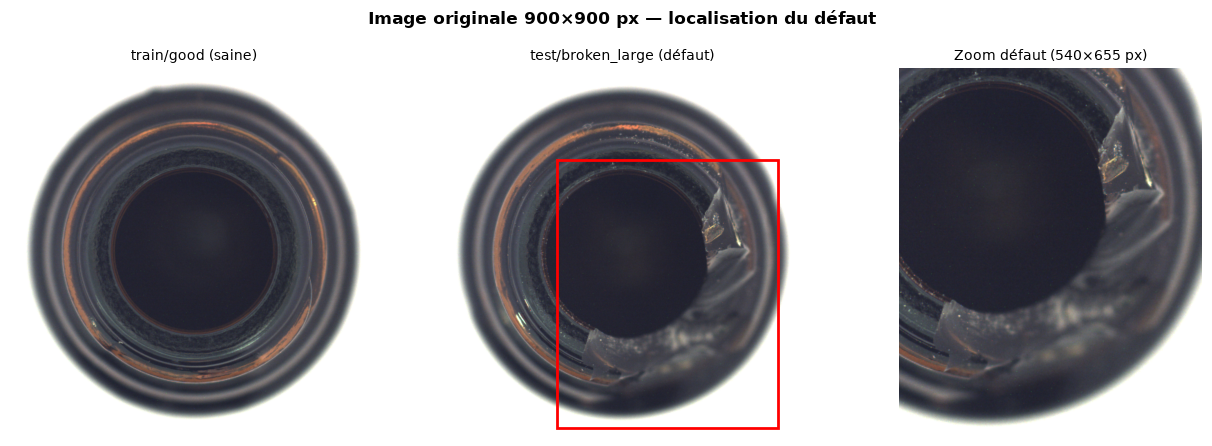

In [7]:
# Trouver la bounding box du masque pour localiser le défaut
rows = np.any(mask_gt, axis=1)
cols = np.any(mask_gt, axis=0)
r0, r1 = np.where(rows)[0][[0, -1]]
c0, c1 = np.where(cols)[0][[0, -1]]
margin = 60
crop = img_defaut[max(0, r0-margin):r1+margin, max(0, c0-margin):c1+margin]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle("Image originale 900×900 px — localisation du défaut", fontsize=12, fontweight="bold")

axes[0].imshow(img_saine)
axes[0].set_title("train/good (saine)", fontsize=10)
axes[0].axis("off")

axes[1].imshow(img_defaut)
rect = patches.Rectangle((c0-margin, r0-margin), (c1-c0+2*margin), (r1-r0+2*margin),
                           linewidth=2, edgecolor="red", facecolor="none")
axes[1].add_patch(rect)
axes[1].set_title("test/broken_large (défaut)", fontsize=10)
axes[1].axis("off")

axes[2].imshow(crop)
axes[2].set_title(f"Zoom défaut ({crop.shape[1]}×{crop.shape[0]} px)", fontsize=10)
axes[2].axis("off")

plt.tight_layout()
plt.savefig("figures/tp2_01_original.png", dpi=120, bbox_inches="tight")
plt.show()

## §2 — Stretch vs Padding : préserver le ratio

Les images `bottle` sont carrées (900×900), donc le ratio est naturellement préservé. Pour illustrer le problème sur des images **non-carrées** (autre catégorie MVTec, ou crop custom), on simule un format 900×600.

In [ ]:
# Simuler une image non-carrée : recadrage 900×600 (3:2)
img_rect = img_defaut[:600, :]           # (600, 900, 3) — format paysage

resized_stretch = resize_stretch(img_rect, size=(256, 256), method="bilinear")
resized_pad     = resize_pad(img_rect,     size=(256, 256), method="lanczos",  fill=0.0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Stretch vs Padding — image non-carrée 900×600 → 256×256", fontsize=12, fontweight="bold")

axes[0].imshow(img_rect)
axes[0].set_title(f"Original\n{img_rect.shape[1]}×{img_rect.shape[0]} px", fontsize=10)
axes[0].axis("off")

axes[1].imshow(resized_stretch)
axes[1].set_title("Stretch (bilinear)\n256×256 — ratio déformé !", fontsize=10, color="#DC2626")
axes[1].axis("off")

axes[2].imshow(resized_pad)
axes[2].set_title("Padding (letterbox)\n256×256 — ratio préservé", fontsize=10, color="#16A34A")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("figures/tp2_02_stretch_vs_pad.png", dpi=150, bbox_inches="tight")
plt.show()

print("Note MVTec bottle : images déjà carrées (900×900) → stretch et pad donnent le même résultat.")
print("Le padding devient critique pour des catégories non-carrées (ex: zipper, wood).")

## §3 — Méthodes d'interpolation

Lors de la réduction 900→256, chaque pixel de sortie est calculé à partir d'un groupe de ~3.5×3.5 pixels d'entrée. La méthode d'interpolation détermine comment ils sont combinés :

| Méthode | Principe | Vitesse | Qualité |
|---------|---------|---------|--------|
| `NEAREST` | Pixel le plus proche — pas de mélange | ★★★★★ | ★☆☆☆☆ |
| `BILINEAR` | Interpolation linéaire 2D | ★★★★☆ | ★★★☆☆ |
| `BICUBIC` | Interpolation cubique — préserve les bords | ★★★☆☆ | ★★★★☆ |
| `LANCZOS` | Filtre sinc tronqué — meilleur pour réduction | ★★☆☆☆ | ★★★★★ |

In [ ]:
methods = compare_interpolations(img_defaut, size=(256, 256))
method_names = ["nearest", "bilinear", "bicubic", "lanczos"]

# Trouver la zone de défaut à l'échelle 256×256
scale = 256 / 900
zr0, zr1 = int(r0 * scale), int(r1 * scale)
zc0, zc1 = int(c0 * scale), int(c1 * scale)
zm = 8
zr0, zr1 = max(0, zr0-zm), min(256, zr1+zm)
zc0, zc1 = max(0, zc0-zm), min(256, zc1+zm)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Comparaison des méthodes d'interpolation (900×900 → 256×256)", fontsize=12, fontweight="bold")

labels = {"nearest": "NEAREST", "bilinear": "BILINEAR", "bicubic": "BICUBIC", "lanczos": "LANCZOS (retenu)"}

for col, name in enumerate(method_names):
    img_r = methods[name]
    zoom  = img_r[zr0:zr1, zc0:zc1]

    axes[0, col].imshow(img_r)
    rect = patches.Rectangle((zc0, zr0), zc1-zc0, zr1-zr0,
                               linewidth=1.5, edgecolor="red", facecolor="none")
    axes[0, col].add_patch(rect)
    color = "#16A34A" if name == "lanczos" else "#1C2E42"
    axes[0, col].set_title(labels[name], fontsize=10, fontweight="bold", color=color)
    axes[0, col].axis("off")

    axes[1, col].imshow(zoom, interpolation="none")
    axes[1, col].set_title(f"Zoom défaut", fontsize=9)
    axes[1, col].axis("off")

fig.text(0.01, 0.73, "Résultat",   va="center", rotation="vertical", fontsize=10, fontweight="bold")
fig.text(0.01, 0.28, "Zoom crack", va="center", rotation="vertical", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("figures/tp2_03_interpolations.png", dpi=150, bbox_inches="tight")
plt.show()

## §4 — Impact de la résolution sur la visibilité des défauts

Plus la résolution cible est basse, plus le facteur de réduction est grand, plus l'information sur le défaut est perdue. L'objectif est de trouver la **résolution minimale** qui préserve suffisamment le signal du défaut.

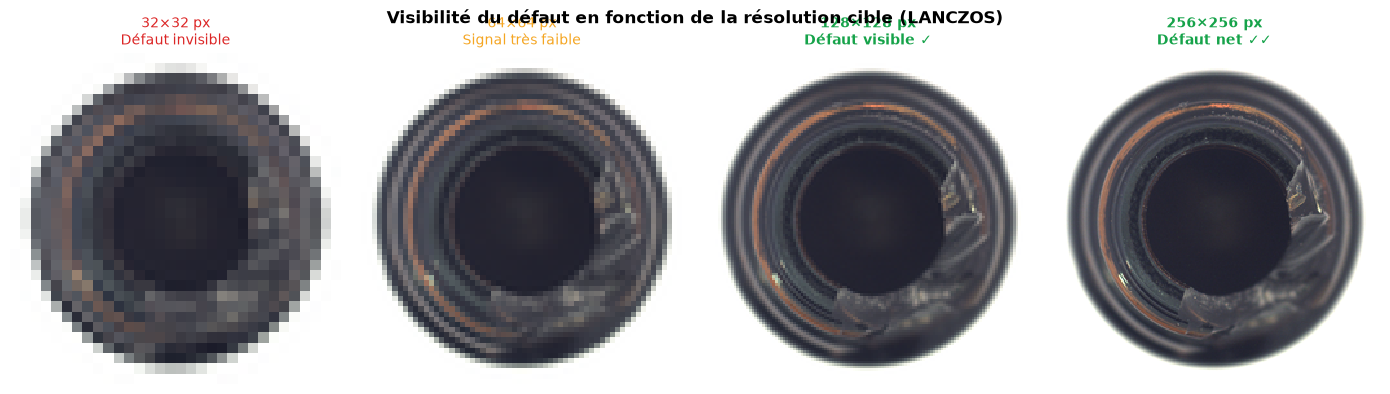

In [10]:
resolutions = [32, 64, 128, 256]
res_imgs = compare_resolutions(img_defaut, resolutions)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle(
    "Visibilité du défaut en fonction de la résolution cible (LANCZOS)",
    fontsize=12, fontweight="bold"
)

comments = {
    32:  "Défaut invisible",
    64:  "Signal très faible",
    128: "Défaut visible ✓",
    256: "Défaut net ✓✓",
}
colors = {32: "#DC2626", 64: "#F5A623", 128: "#16A34A", 256: "#16A34A"}

for col, r in enumerate(resolutions):
    axes[col].imshow(res_imgs[r], interpolation="none")
    axes[col].set_title(
        f"{r}×{r} px\n{comments[r]}",
        fontsize=10,
        fontweight="bold" if r >= 128 else "normal",
        color=colors[r]
    )
    axes[col].axis("off")
    # Cadre vert/rouge
    for spine in axes[col].spines.values():
        spine.set_edgecolor(colors[r])
        spine.set_linewidth(2)
        spine.set_visible(True)

# Annotation facteur de réduction
for col, r in enumerate(resolutions):
    factor = 900 / r
    axes[col].set_xlabel(f"Facteur ÷{factor:.0f}", fontsize=8.5, color="#4E6680")

plt.tight_layout()
plt.savefig("figures/tp2_04_resolutions.png", dpi=150, bbox_inches="tight")
plt.show()

## §5 — Justification du choix : 256×256 + LANCZOS

### Résolution : 256×256

- **32×32** : défaut invisible (facteur ÷28) — inutilisable.
- **64×64** : signal très faible — l'auto-encodeur aurait du mal à apprendre la différence.
- **128×128** : défaut visible, compromis acceptable.
- **256×256** ✓ : défaut net, résolution suffisante pour que le signal d'anomalie soit clair. Facteur de réduction ÷3.5 — information préservée.

**Choix retenu** : 256×256 (consigne formateur). En production c'est aussi la cible préférable si le budget compute le permet.

### Interpolation : LANCZOS

Pour une **réduction** (900 → 256), LANCZOS est le meilleur filtre : il applique un noyau sinc pour limiter l'aliasing tout en préservant les bords du défaut. NEAREST produit des artéfacts de pixellisation ; BILINEAR et BICUBIC sont des compromis acceptables mais inférieurs à LANCZOS sur des réductions importantes.

### Stratégie : Stretch (images carrées) ou Pad (images non-carrées)

Pour `bottle` (900×900), stretch = pad. Sur d'autres catégories MVTec non-carrées (`zipper`, `wood`…), le **padding centré** est obligatoire pour éviter la déformation — une bouteille écrasée aurait un profil différent de ce que le modèle a appris.

```python
# Résumé du pipeline de chargement retenu
from indusense.vision.resize import resize_pad

TARGET_SIZE = (256, 256)
METHOD      = "lanczos"

# Padding centré (letterbox) — ratio préservé
img_ready = resize_pad(img_original, size=TARGET_SIZE, method=METHOD)
# img_ready : (256, 256, 3) float32 in [0, 1]
```